## ANALISIS DE LA CALIDAD DEL VINO

En este proyecto se realizará un análisis de la calidad del vino utilizando técnicas de aprendizaje automático. 
Se utilizará un conjunto de datos que contiene información sobre diferentes características químicas del vino y su calidad,
con el objetivo de construir un modelo que pueda predecir la calidad del vino en función a estas características.

# Fase de Exploración:
Contamos con un dataset con 1600 filas en las que se recogen 12 variables, 11 de ellas corresponden a características del vino y la última la calidad, con valores entre el 0 y el 10, que es la variable objetivo que trataremos de predecir.

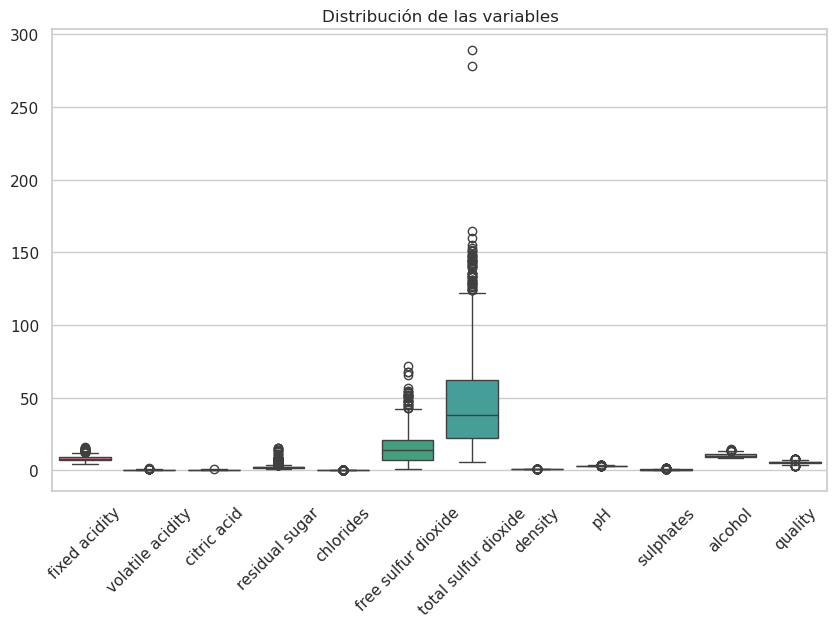

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Cargar dataset
df = pd.read_csv('winequality-red.csv')

# Observamos la distribución de las variables para tratar la normalización
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)

plt.title('Distribución de las variables')
plt.xticks(rotation=45)
plt.show()


Vemos una clara distribución asimétrica en las variables relacionadas al dióxido de azufre, lo que nos obliga a estandarizar las variables a la hora de llevar a cabo el modelo.

A continuación analizaremos la crrelación entrer las variables para ver cuales son las más relacionadas con la calidad del vino.

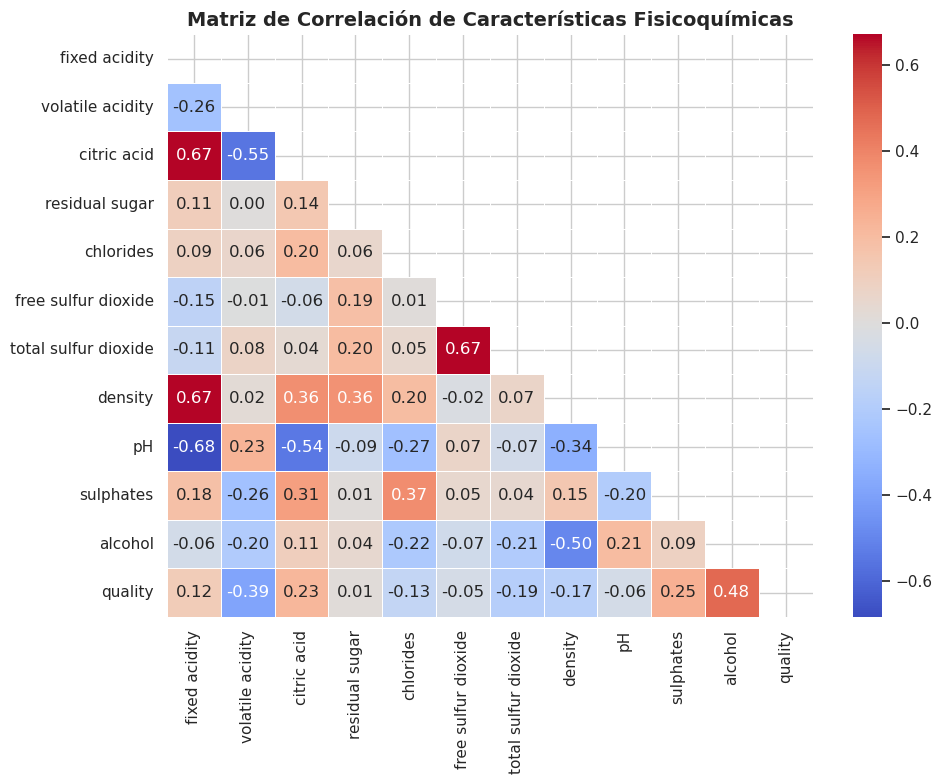

In [2]:
# Mapa de Calor de Correlación
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title('Matriz de Correlación de Características Fisicoquímicas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=300)
plt.show()



Vemos como el alchol es un gran predictor de la calidad del vino, con una correlación de 0.44, por lo que los vinos más graduados tienden a ser mejor valorados. Por otro lado factores como la densidad o la acidez están relacionados con peor calidad del vino. 

# Fase de Modelización
Comenzaremos separando los datos en conjuntos de train, validación y test mediante el método de validación cruzada para una mejor selección del modelo.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Comenzamos transformando los vinos en buenos o malos en funcino a su calidad.
df = df.dropna()
df['quality'] = df['quality'].apply(lambda x: 'good' if x >= 7 else 'bad')

X = df.drop(columns=['quality'])
y = df['quality']

X_train, X_test, ytrain, ytest = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Estandarización de los datos
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(X_train)
Xtest_scaled = scaler.transform(X_test)


# Usar un clasificador en lugar de regresión lineal
model = LogisticRegression(max_iter=1000)
model.fit(Xtrain_scaled, ytrain)

# Predicción en train usando datos de train
y_pred_train = model.predict(Xtrain_scaled)
y_pred_final = model.predict(Xtest_scaled)
acc_train = accuracy_score(ytrain, y_pred_train)
acc_test = accuracy_score(ytest, y_pred_final)

print("Accuracy en train: {:.4f}".format(acc_train))
print("Accuracy en test: {:.4f}".format(acc_test))

Accuracy en train: 0.8858
Accuracy en test: 0.8656


Finalizamos el proyecto con un 88,58% en el train y un 86,56% en el test